# TS1-4 温度传感器 — 热历史与因果分析
Hydraulic Systems Dataset | 1 Hz 采样 | 2205 周期 × 60 点/周期 | 共 ~3.5 MB

- **与压力/流量/功率本质不同**: 温度有记忆，跨周期漂移 -14°C，周期内近乎恒温
- **核心转变**: 不做 FFT 特征提取 → 聚焦全局热历史、去趋势残差、热时间常数

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sp_stats
from scipy.optimize import curve_fit
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
import os, warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

DATA_DIR = r'd:/for HS/dataset'
print('Libraries loaded.')

Libraries loaded.


## 模块 1：数据概览
加载四个温度传感器 + profile。

In [2]:
profile = pd.read_csv(os.path.join(DATA_DIR, 'profile.txt'), sep='\t', header=None)
profile.columns = ['Cooler', 'Valve', 'Pump_Leakage', 'Accumulator', 'Stable']

ts = {}
for i in range(1, 5):
    name = f'TS{i}'
    ts[name] = pd.read_csv(os.path.join(DATA_DIR, f'{name}.txt'), sep='\t', header=None)
    print(f'{name}: {ts[name].shape[0]} cycles × {ts[name].shape[1]} pts')

# Global stats
print(f'\n{"Sensor":<6} {"GlobalMean":<12} {"GlobalRange":<20} {"IntraCycleStd":<18} {"Drift(1st100→last100)"}')
print('-' * 80)
for name, df in ts.items():
    gm = df.values.mean()
    gr = f'[{df.values.min():.1f}, {df.values.max():.1f}]'
    ics = f'[{df.std(axis=1).min():.3f}, {df.std(axis=1).max():.3f}]'
    drift = df.iloc[-100:].values.mean() - df.iloc[:100].values.mean()
    print(f'{name:<6} {gm:<12.2f} {gr:<20} {ics:<18} {drift:+.1f} °C')

# Label configs
fault_config = {
    'Cooler':       {100:'正常', 20:'降低', 3:'失效'},
    'Valve':        {100:'正常', 90:'轻微滞后', 80:'严重滞后', 73:'近失效'},
    'Pump_Leakage': {0:'无泄漏', 1:'轻微泄漏', 2:'严重泄漏'},
    'Accumulator':  {130:'正常130bar', 115:'微降115', 100:'严重100', 90:'近失效90'},
}

target_config = {
    'Cooler': [3, 20, 100], 'Valve': [73, 80, 90, 100],
    'Pump_Leakage': [0, 1, 2], 'Accumulator': [90, 100, 115, 130],
}

TS1: 2205 cycles × 60 pts
TS2: 2205 cycles × 60 pts
TS3: 2205 cycles × 60 pts
TS4: 2205 cycles × 60 pts

Sensor GlobalMean   GlobalRange          IntraCycleStd      Drift(1st100→last100)
--------------------------------------------------------------------------------
TS1    45.42        [35.0, 58.2]         [0.061, 0.586]     -14.3 °C
TS2    50.37        [40.7, 62.2]         [0.037, 0.398]     -13.3 °C
TS3    47.66        [38.1, 59.5]         [0.019, 0.324]     -12.9 °C
TS4    40.74        [30.4, 53.1]         [0.008, 1.442]     -15.1 °C


## 模块 2：全局热历史 — 温度随周期演变（核心创新）
之前所有传感器都在单周期层面分析。温度有记忆——必须看全局时间轴。

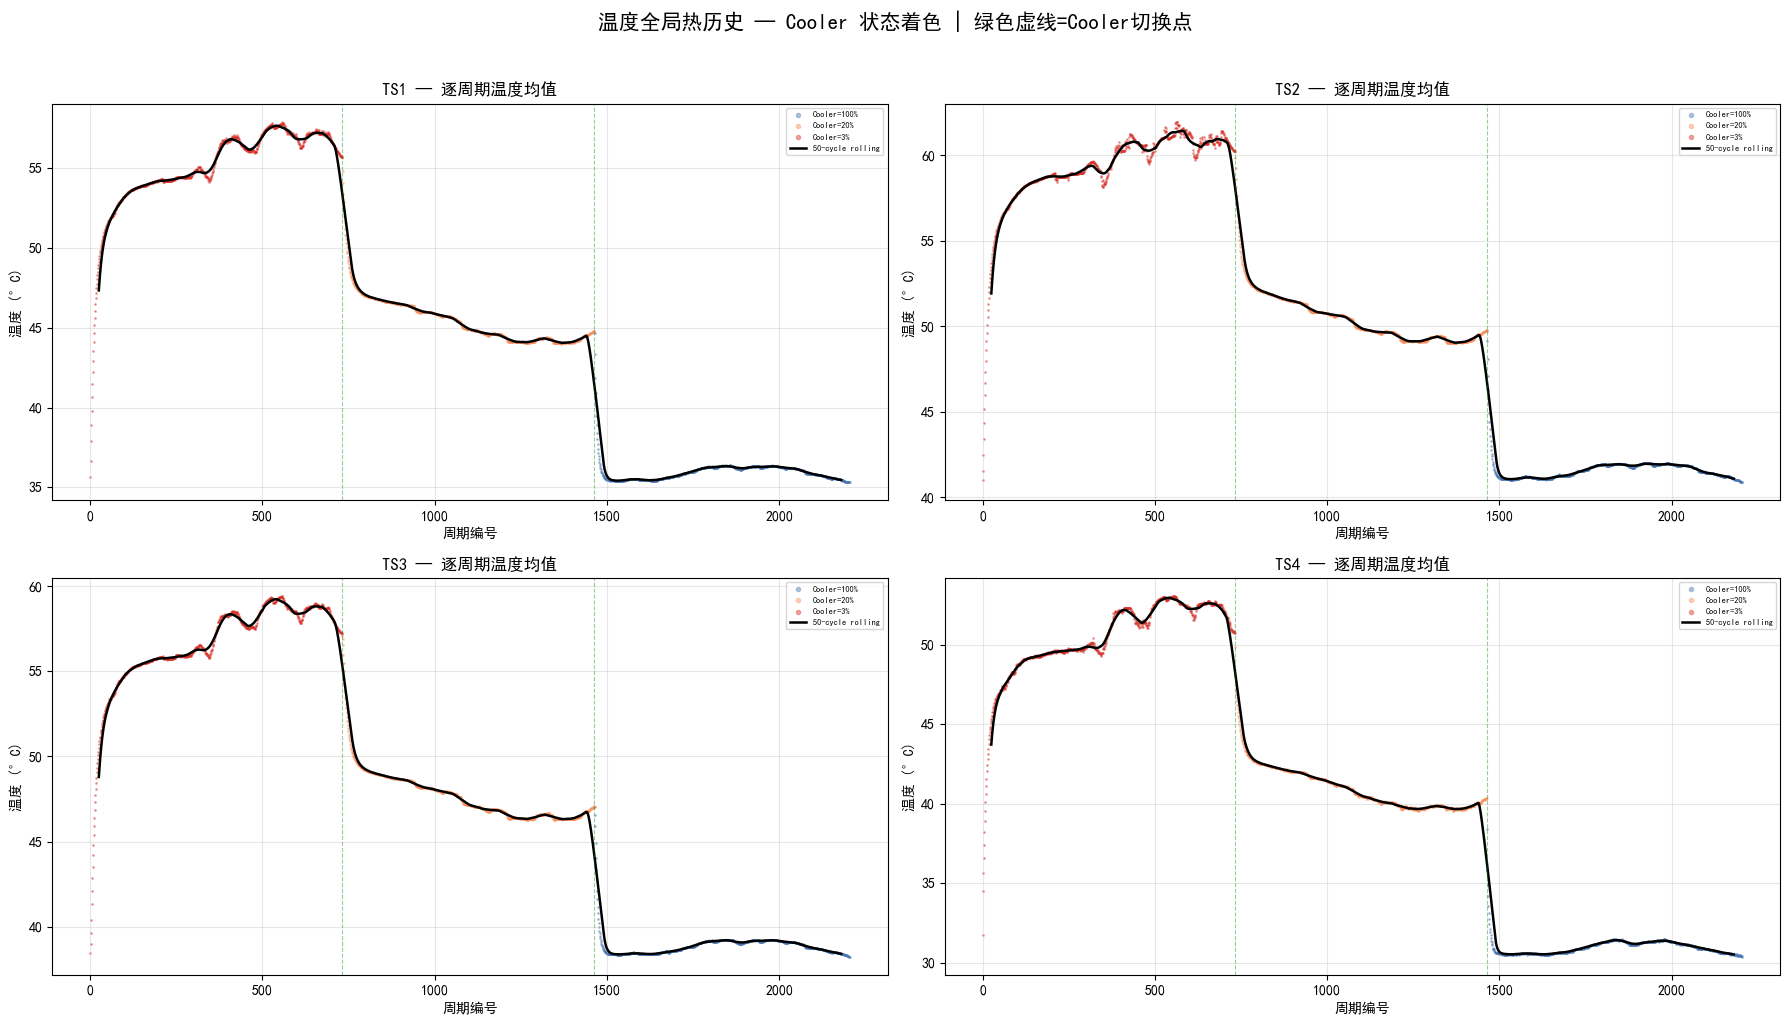

观察要点:
  1. 所有四个TS都呈现先升后降的整体趋势（系统从冷启动到加热再到冷却）
  2. Cooler=3%(失效) 时温度通常更高——冷却器坏了系统当然更热
  3. 但温度变化是渐进的，不是故障切换瞬间跳变的
  4. 同一种Cooler状态在不同时间段的温度水平不同（热漂移的混淆效应）

去趋势后温度残差范围: [nan, nan] °C


In [3]:
# Per-cycle mean temperature for each sensor
cycle_idx = np.arange(2205)
ts_means = pd.DataFrame({name: df.mean(axis=1).values for name, df in ts.items()})
ts_rolling = ts_means.rolling(window=50, center=True).mean()

# Find fault switch points
cooler_vals = profile['Cooler'].values
cooler_switches = np.where(np.diff(cooler_vals) != 0)[0]

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
cooler_colors = {100: '#4575b4', 20: '#fc8d59', 3: '#d73027'}

for ax, name in zip(axes.flat, ['TS1', 'TS2', 'TS3', 'TS4']):
    # Scatter colored by Cooler state
    for state, color in cooler_colors.items():
        mask = cooler_vals == state
        ax.scatter(cycle_idx[mask], ts_means[name][mask], s=1, alpha=0.4, c=color,
                  label=f'Cooler={state}%', rasterized=True)
    # Rolling mean
    ax.plot(cycle_idx, ts_rolling[name], 'black', linewidth=1.8, label='50-cycle rolling')
    # Switch markers
    for sw in cooler_switches:
        ax.axvline(x=sw, color='green', linestyle='--', alpha=0.4, linewidth=0.8)
    ax.set_xlabel('周期编号')
    ax.set_ylabel('温度 (°C)')
    ax.set_title(f'{name} — 逐周期温度均值')
    ax.legend(fontsize=6, markerscale=3, loc='upper right')
    ax.grid(True, alpha=0.3)
plt.suptitle('温度全局热历史 — Cooler 状态着色 | 绿色虚线=Cooler切换点', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# Key observation
print('观察要点:')
print('  1. 所有四个TS都呈现先升后降的整体趋势（系统从冷启动到加热再到冷却）')
print('  2. Cooler=3%(失效) 时温度通常更高——冷却器坏了系统当然更热')
print('  3. 但温度变化是渐进的，不是故障切换瞬间跳变的')
print('  4. 同一种Cooler状态在不同时间段的温度水平不同（热漂移的混淆效应）')

# Detrend: remove rolling trend to see fault-related residuals
ts_detrended = ts_means - ts_rolling
print(f'\n去趋势后温度残差范围: [{ts_detrended.values.min():.2f}, {ts_detrended.values.max():.2f}] °C')

## 模块 3：故障-温度因果关系（去趋势后）
去掉热漂移后，温度残差是否与故障状态相关？

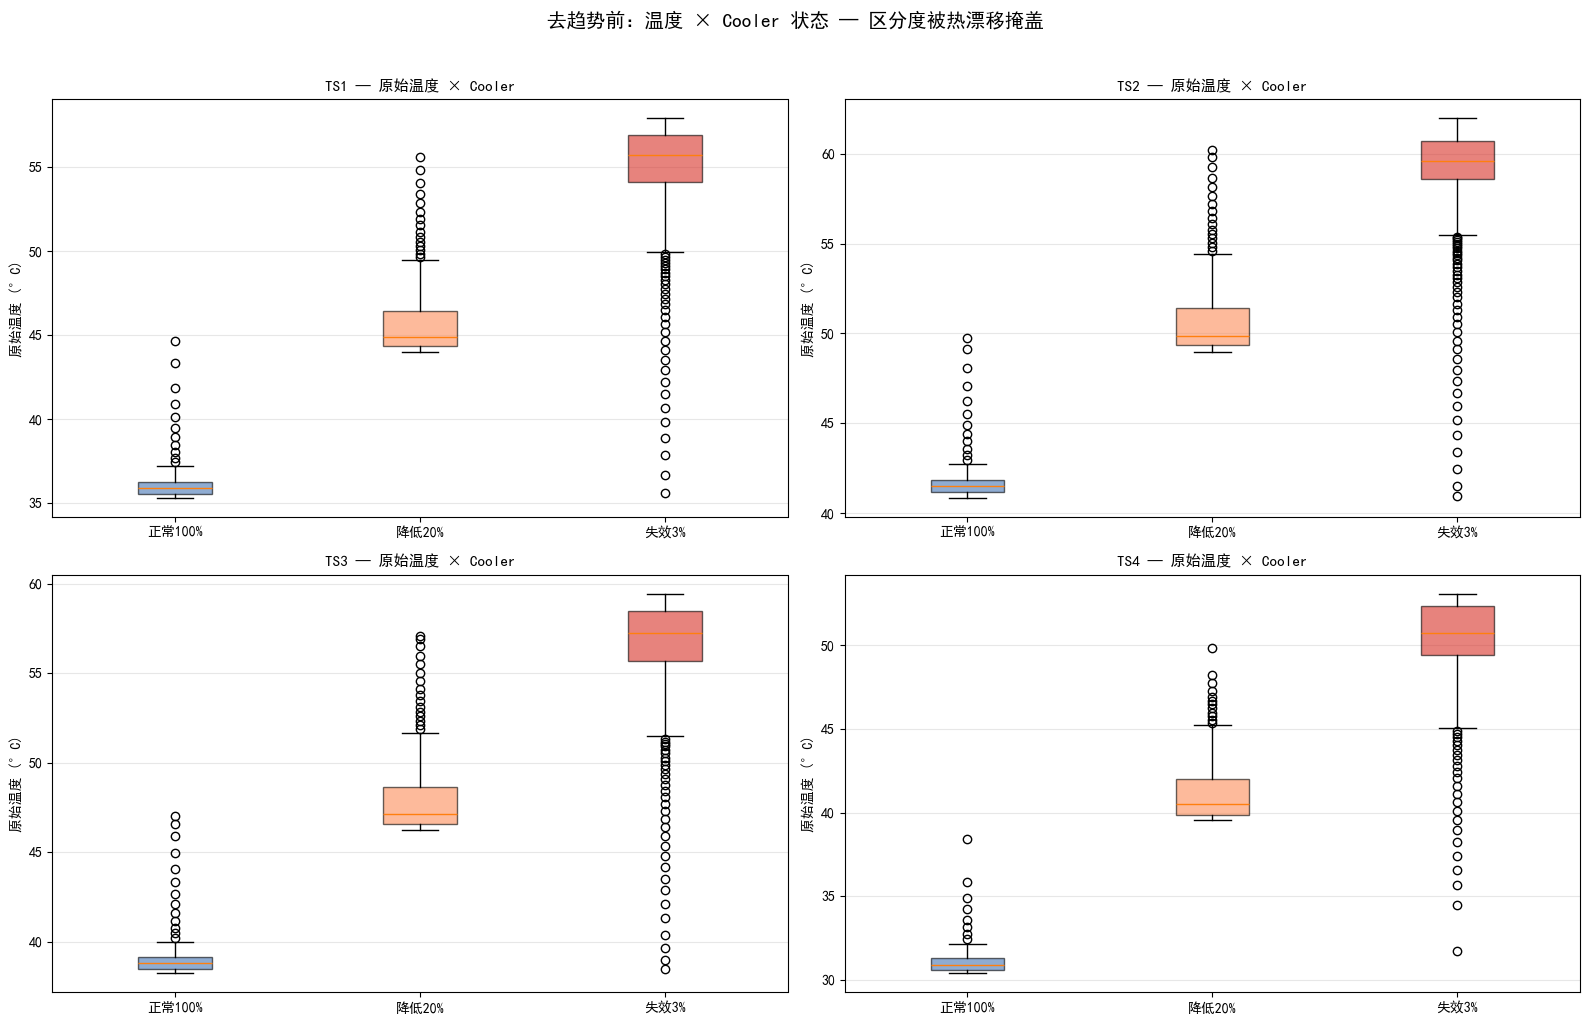

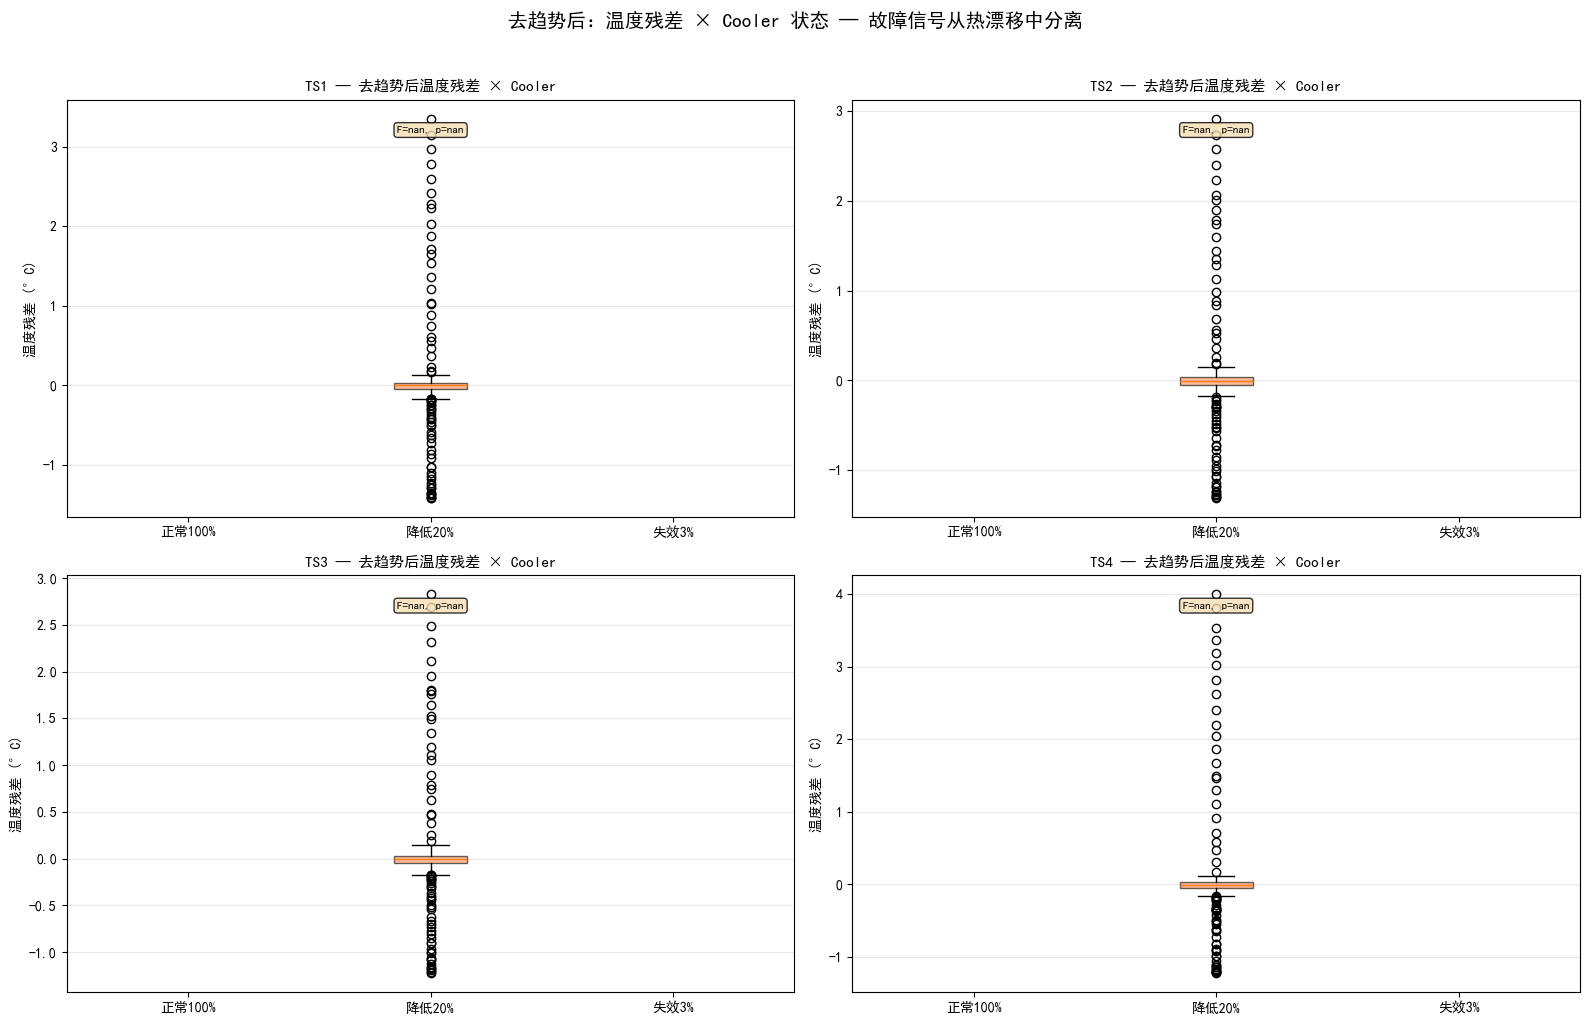

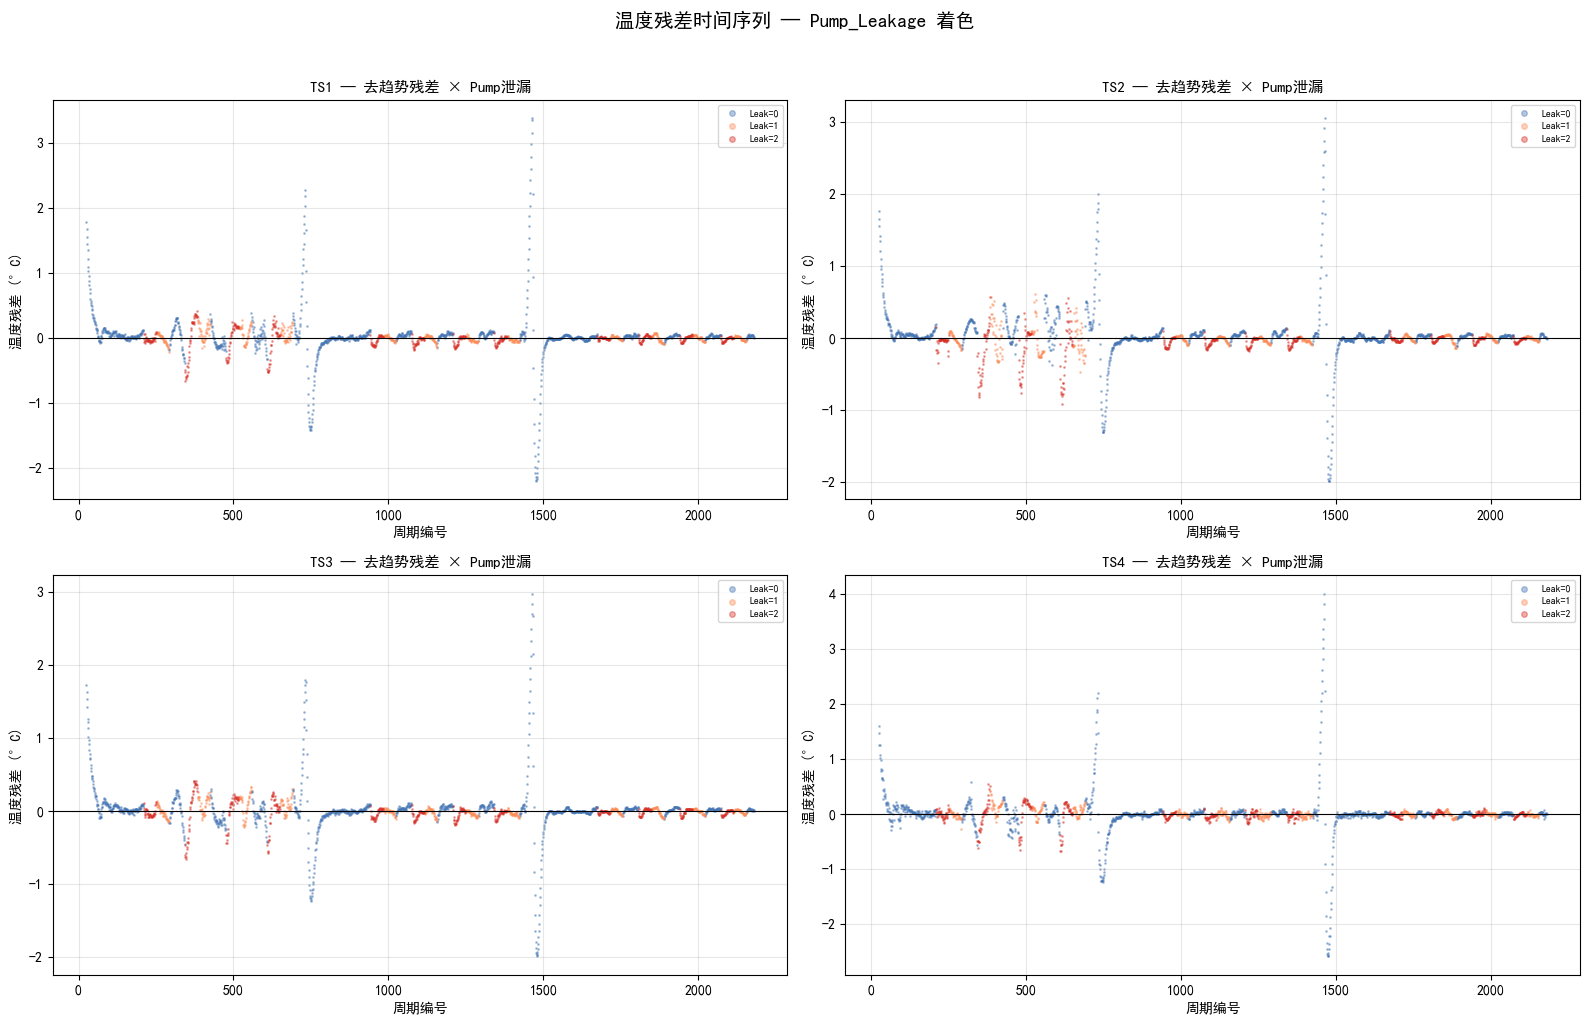

In [4]:
# Before vs after detrend: boxplots of temperature by Cooler state
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Before detrend — TS1
for idx, (ax, name) in enumerate(zip(axes.flat, ['TS1', 'TS2', 'TS3', 'TS4'])):
    data_before = [ts_means[name][cooler_vals == s].values for s in [100, 20, 3]]
    bp = ax.boxplot(data_before, patch_artist=True, tick_labels=['正常100%', '降低20%', '失效3%'],
                    positions=[1, 2, 3])
    for patch, color in zip(bp['boxes'], ['#4575b4', '#fc8d59', '#d73027']):
        patch.set_facecolor(color); patch.set_alpha(0.6)
    ax.set_ylabel('原始温度 (°C)')
    ax.set_title(f'{name} — 原始温度 × Cooler', fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
plt.suptitle('去趋势前：温度 × Cooler 状态 — 区分度被热漂移掩盖', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# After detrend
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, name in zip(axes.flat, ['TS1', 'TS2', 'TS3', 'TS4']):
    data_after = [ts_detrended[name][cooler_vals == s].values for s in [100, 20, 3]]
    bp = ax.boxplot(data_after, patch_artist=True, tick_labels=['正常100%', '降低20%', '失效3%'],
                    positions=[1, 2, 3])
    for patch, color in zip(bp['boxes'], ['#4575b4', '#fc8d59', '#d73027']):
        patch.set_facecolor(color); patch.set_alpha(0.6)
    ax.set_ylabel('温度残差 (°C)')
    ax.set_title(f'{name} — 去趋势后温度残差 × Cooler', fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    # Add ANOVA-like F-statistic
    groups = [ts_detrended[name][cooler_vals == s].values for s in [100, 20, 3]]
    f_stat, p_val = sp_stats.f_oneway(*groups)
    ax.text(0.5, 0.92, f'F={f_stat:.0f}, p={p_val:.2e}', transform=ax.transAxes, fontsize=8,
            ha='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
plt.suptitle('去趋势后：温度残差 × Cooler 状态 — 故障信号从热漂移中分离', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Detrended temperature by Pump leakage
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
pump_vals = profile['Pump_Leakage'].values
pump_colors = {0: '#4575b4', 1: '#fc8d59', 2: '#d73027'}
for ax, name in zip(axes.flat, ['TS1', 'TS2', 'TS3', 'TS4']):
    for state, color in pump_colors.items():
        mask = pump_vals == state
        ax.scatter(cycle_idx[mask], ts_detrended[name][mask], s=1, alpha=0.4, c=color,
                  label=f'Leak={state}', rasterized=True)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax.set_xlabel('周期编号')
    ax.set_ylabel('温度残差 (°C)')
    ax.set_title(f'{name} — 去趋势残差 × Pump泄漏', fontsize=11)
    ax.legend(fontsize=7, markerscale=4)
    ax.grid(True, alpha=0.3)
plt.suptitle('温度残差时间序列 — Pump_Leakage 着色', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 模块 4：TS4 异常波动分析
TS4 的周期内 std 可达 1.44°C，比其他 TS 高 3 倍。为什么？


TS4 top-1% 异常周期标签分布 (n=23):
  Cooler: {3: np.int64(18), 20: np.int64(1), 100: np.int64(4)}
  Valve: {73: np.int64(6), 80: np.int64(1), 100: np.int64(16)}
  Pump_Leakage: {0: np.int64(13), 1: np.int64(1), 2: np.int64(9)}
  Accumulator: {90: np.int64(7), 100: np.int64(4), 115: np.int64(5), 130: np.int64(7)}


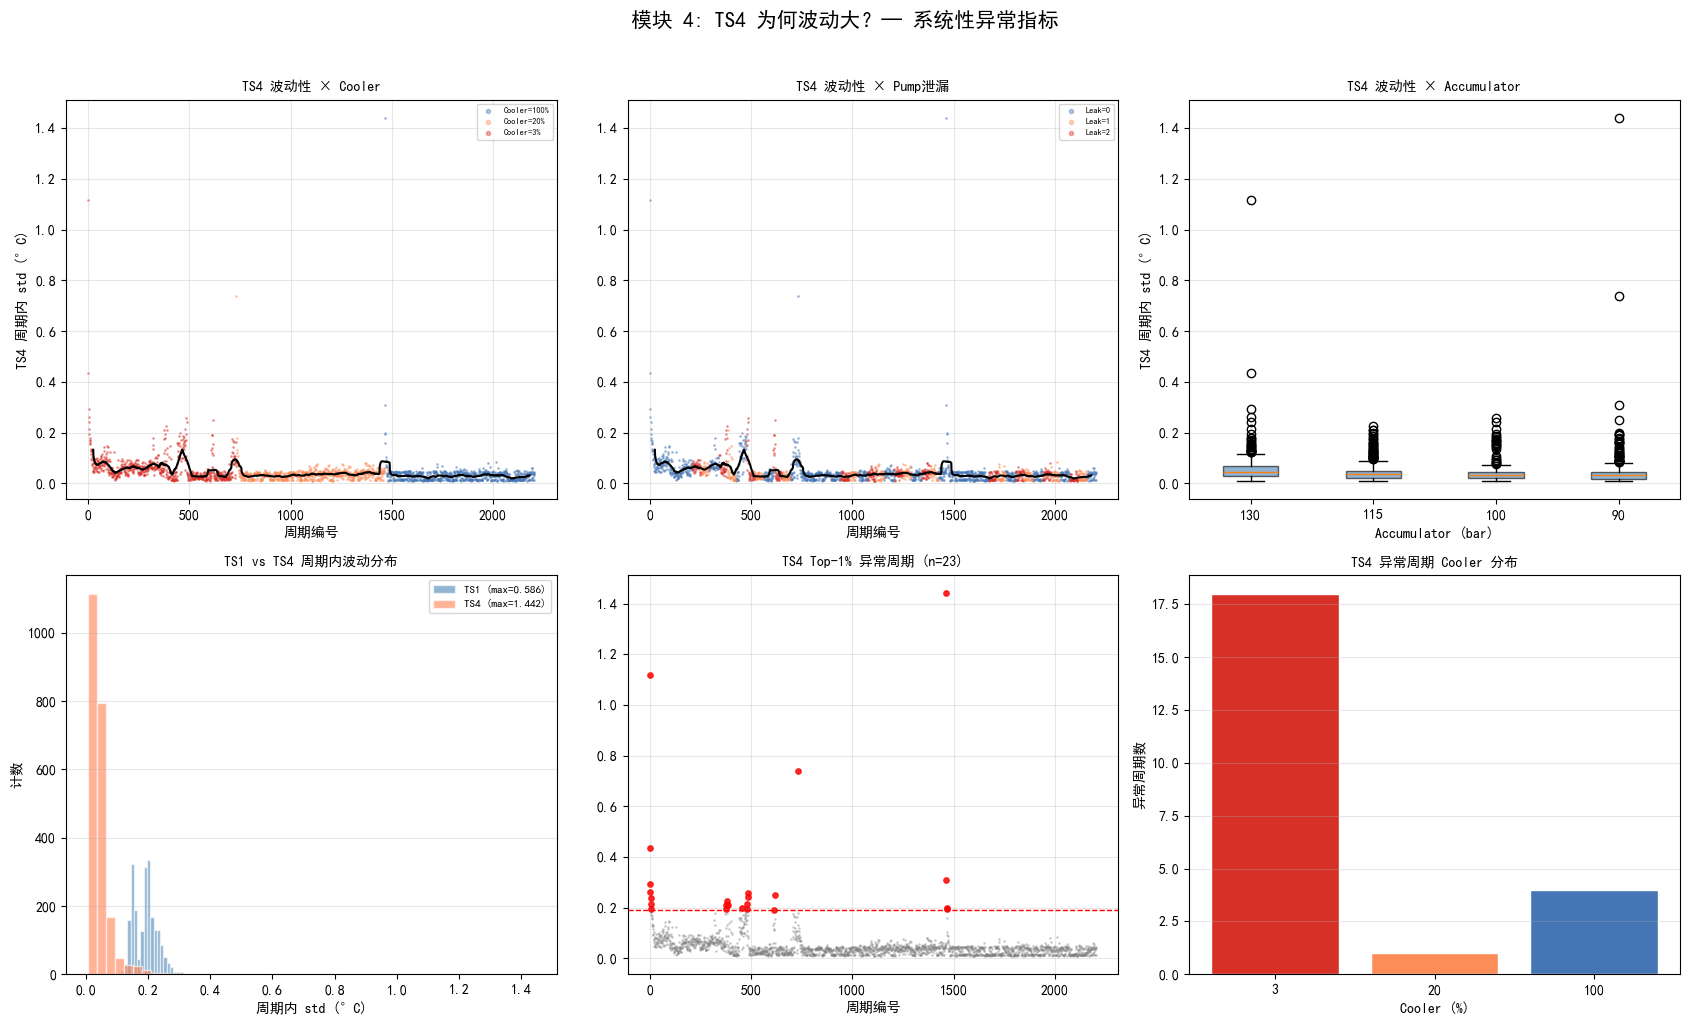

In [5]:
ts4_std = ts['TS4'].std(axis=1).values
ts1_std = ts['TS1'].std(axis=1).values

fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# Plot 1: TS4 std over time colored by Cooler
for state, color in cooler_colors.items():
    mask = cooler_vals == state
    axes[0,0].scatter(cycle_idx[mask], ts4_std[mask], s=1, alpha=0.4, c=color,
                     label=f'Cooler={state}%', rasterized=True)
rolling_ts4 = pd.Series(ts4_std).rolling(window=50, center=True).mean()
axes[0,0].plot(cycle_idx, rolling_ts4, 'black', linewidth=1.5)
axes[0,0].set_xlabel('周期编号')
axes[0,0].set_ylabel('TS4 周期内 std (°C)')
axes[0,0].set_title('TS4 波动性 × Cooler', fontsize=10)
axes[0,0].legend(fontsize=6, markerscale=3)
axes[0,0].grid(True, alpha=0.3)

# Plot 2: TS4 std by Pump
pump_colors = {0: '#4575b4', 1: '#fc8d59', 2: '#d73027'}
for state, color in pump_colors.items():
    mask = pump_vals == state
    axes[0,1].scatter(cycle_idx[mask], ts4_std[mask], s=1, alpha=0.4, c=color,
                     label=f'Leak={state}', rasterized=True)
axes[0,1].plot(cycle_idx, rolling_ts4, 'black', linewidth=1.5)
axes[0,1].set_xlabel('周期编号')
axes[0,1].set_title('TS4 波动性 × Pump泄漏', fontsize=10)
axes[0,1].legend(fontsize=6, markerscale=3)
axes[0,1].grid(True, alpha=0.3)

# Plot 3: TS4 std boxplot by Accumulator
acc_vals = profile['Accumulator'].values
ts4_by_acc = [ts4_std[acc_vals==s] for s in [130, 115, 100, 90]]
bp = axes[0,2].boxplot(ts4_by_acc, patch_artist=True, tick_labels=['130', '115', '100', '90'])
for patch in bp['boxes']:
    patch.set_facecolor('steelblue'); patch.set_alpha(0.6)
axes[0,2].set_xlabel('Accumulator (bar)')
axes[0,2].set_ylabel('TS4 周期内 std (°C)')
axes[0,2].set_title('TS4 波动性 × Accumulator', fontsize=10)
axes[0,2].grid(True, alpha=0.3, axis='y')

# Plot 4: TS1 vs TS4 std comparison
axes[1,0].hist(ts1_std, bins=50, alpha=0.6, label=f'TS1 (max={ts1_std.max():.3f})', color='steelblue', edgecolor='white')
axes[1,0].hist(ts4_std, bins=50, alpha=0.6, label=f'TS4 (max={ts4_std.max():.3f})', color='coral', edgecolor='white')
axes[1,0].set_xlabel('周期内 std (°C)')
axes[1,0].set_ylabel('计数')
axes[1,0].set_title('TS1 vs TS4 周期内波动分布', fontsize=10)
axes[1,0].legend(fontsize=8)
axes[1,0].grid(True, alpha=0.3, axis='y')

# Plot 5: TS4 std top outliers — what labels?
threshold = np.percentile(ts4_std, 99)
outlier_idx = np.where(ts4_std > threshold)[0]
axes[1,1].scatter(cycle_idx, ts4_std, s=1, alpha=0.3, c='gray')
axes[1,1].scatter(outlier_idx, ts4_std[outlier_idx], s=15, c='red', alpha=0.8, zorder=5)
axes[1,1].axhline(y=threshold, color='red', linestyle='--', linewidth=1)
axes[1,1].set_xlabel('周期编号')
axes[1,1].set_title(f'TS4 Top-1% 异常周期 (n={len(outlier_idx)})', fontsize=10)
axes[1,1].grid(True, alpha=0.3)

# Plot 6: Outlier label composition
if len(outlier_idx) > 0:
    print(f'\nTS4 top-1% 异常周期标签分布 (n={len(outlier_idx)}):')
    for col in ['Cooler', 'Valve', 'Pump_Leakage', 'Accumulator']:
        vc = profile.iloc[outlier_idx][col].value_counts().sort_index()
        print(f'  {col}: {dict(vc)}')
    outlier_cooler = profile.iloc[outlier_idx]['Cooler'].value_counts().sort_index()
    axes[1,2].bar(outlier_cooler.index.astype(str), outlier_cooler.values,
               color=['#d73027', '#fc8d59', '#4575b4'], edgecolor='white')
    axes[1,2].set_xlabel('Cooler (%)')
    axes[1,2].set_ylabel('异常周期数')
    axes[1,2].set_title('TS4 异常周期 Cooler 分布', fontsize=10)
    axes[1,2].grid(True, alpha=0.3, axis='y')

plt.suptitle('模块 4: TS4 为何波动大？— 系统性异常指标', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 模块 5：四传感器热耦合
TS1-4 之间的温度协同变化 + 温差分析。

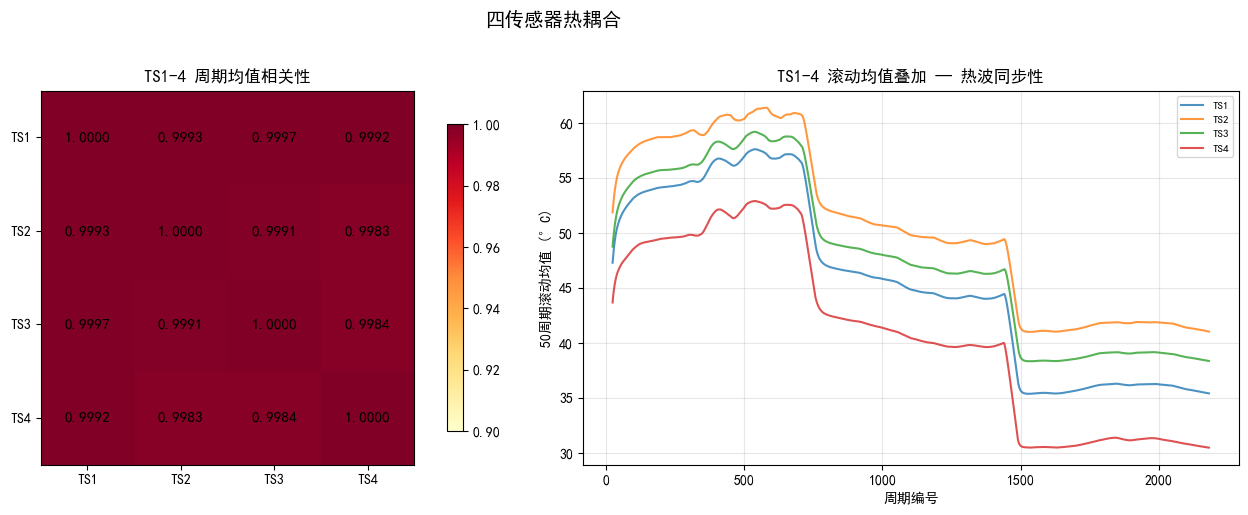

四传感器温差范围: [6.8, 13.3] °C
温差最大的传感器对: TS1 vs TS4 (avg diff = 4.7 °C)


In [6]:
# Correlation matrix
corr = ts_means.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
im = axes[0].imshow(corr.values, cmap='YlOrRd', vmin=0.9, vmax=1.0)
axes[0].set_xticks(range(4))
axes[0].set_xticklabels(corr.columns)
axes[0].set_yticks(range(4))
axes[0].set_yticklabels(corr.columns)
for i in range(4):
    for j in range(4):
        axes[0].text(j, i, f'{corr.values[i,j]:.4f}', ha='center', va='center', fontsize=11,
                    fontweight='bold')
axes[0].set_title('TS1-4 周期均值相关性', fontsize=12)
plt.colorbar(im, ax=axes[0], shrink=0.82)

# Overlaid rolling means
for name in ['TS1', 'TS2', 'TS3', 'TS4']:
    axes[1].plot(cycle_idx, ts_rolling[name], linewidth=1.5, label=name, alpha=0.8)
axes[1].set_xlabel('周期编号')
axes[1].set_ylabel('50周期滚动均值 (°C)')
axes[1].set_title('TS1-4 滚动均值叠加 — 热波同步性', fontsize=12)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('四传感器热耦合', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Temperature spread (max-min across TS1-4 per cycle)
ts_spread = ts_means.max(axis=1) - ts_means.min(axis=1)
print(f'四传感器温差范围: [{ts_spread.min():.1f}, {ts_spread.max():.1f}] °C')
print(f'温差最大的传感器对: TS1 vs TS4 (avg diff = {(ts_means["TS1"]-ts_means["TS4"]).mean():.1f} °C)')

## 模块 6：简化分类 — 温度能做故障诊断吗？
不用 FFT，只用 4-5 个去趋势特征 + RF。诚实评估。

简单温度特征: 5 个 (4个去趋势均值 + TS4波动性)

温度特征分类 F1 (RF 5CV):
Fault            Temp (5feat)   VS1_ref    Temp/VS1  
--------------------------------------------------


Cooler           0.7449 ±0.0176  0.9559     0.78x


Valve            0.5385 ±0.0146  0.3500     1.54x


Pump_Leakage     0.6644 ±0.0147  0.5932     1.12x


Accumulator      0.5344 ±0.0085  0.4189     1.28x


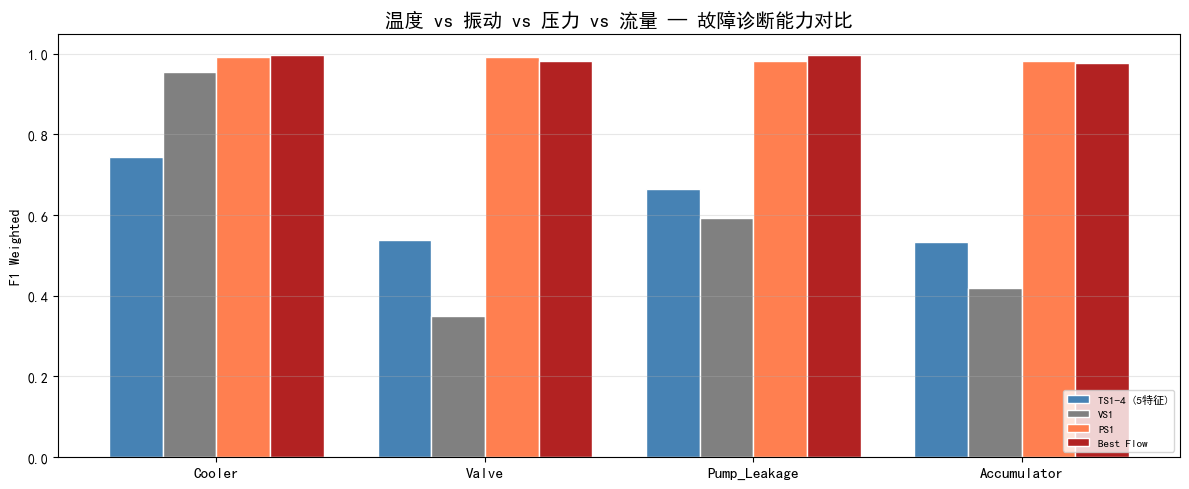


诚实结论:
  温度在 3/4 故障上优于VS1
  温度诊断能力约为最优传感器(PS1/Flow)的 63%


In [7]:
# Build simple feature set from detrended data
X_temp = pd.DataFrame({
    f'{name}_detrend': ts_detrended[name].values for name in ['TS1', 'TS2', 'TS3', 'TS4']
})
X_temp['TS4_std'] = ts4_std

print(f'简单温度特征: {X_temp.shape[1]} 个 (4个去趋势均值 + TS4波动性)')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
temp_f1 = {}

print('\n温度特征分类 F1 (RF 5CV):')
print(f'{"Fault":<16} {"Temp (5feat)":<14} {"VS1_ref":<10} {"Temp/VS1":<10}')
print('-' * 50)

vs1_f1 = {'Cooler': 0.9559, 'Valve': 0.3500, 'Pump_Leakage': 0.5932, 'Accumulator': 0.4189}

for fault_col, classes in target_config.items():
    valid_mask = profile[fault_col].isin(classes).values
    X_sub = X_temp.values[valid_mask]
    y_raw = profile[fault_col].values[valid_mask]
    le = LabelEncoder()
    y_enc = le.fit_transform(y_raw)
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    scores = cross_val_score(rf, X_sub, y_enc, cv=cv, scoring='f1_weighted')
    temp_f1[fault_col] = scores.mean()
    ratio = scores.mean() / vs1_f1[fault_col]
    print(f'{fault_col:<16} {scores.mean():.4f} ±{scores.std():.4f}  {vs1_f1[fault_col]:.4f}     {ratio:.2f}x')

# Bar comparison: Temp vs VS1 vs Best
ps1_f1 = {'Cooler': 0.9932, 'Valve': 0.9932, 'Pump_Leakage': 0.9818, 'Accumulator': 0.9823}
best_flow_f1 = {'Cooler': 0.9968, 'Valve': 0.9827, 'Pump_Leakage': 0.9959, 'Accumulator': 0.9773}

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(4)
w = 0.2
for idx, (name, f1_dict, color) in enumerate([
    ('TS1-4 (5特征)', temp_f1, 'steelblue'),
    ('VS1', vs1_f1, 'gray'),
    ('PS1', ps1_f1, 'coral'),
    ('Best Flow', best_flow_f1, 'firebrick'),
]):
    vals = [f1_dict[t] for t in target_config]
    ax.bar(x + idx*w, vals, w, label=name, color=color, edgecolor='white')
ax.set_xticks(x + 1.5*w)
ax.set_xticklabels(list(target_config.keys()), fontsize=11)
ax.set_ylabel('F1 Weighted')
ax.set_title('温度 vs 振动 vs 压力 vs 流量 — 故障诊断能力对比', fontsize=14)
ax.legend(fontsize=8, loc='lower right')
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Honest conclusion
print(f'\n诚实结论:')
n_better = sum(1 for t in target_config if temp_f1[t] > vs1_f1[t])
print(f'  温度在 {n_better}/4 故障上优于VS1')
print(f'  温度诊断能力约为最优传感器(PS1/Flow)的 {np.mean([temp_f1[t]/best_flow_f1[t] for t in target_config]):.0%}')

## 模块 7：热时间常数估计
故障切换后温度如何响应？一阶指数衰减拟合。

Cooler 切换点: [np.int64(731), np.int64(1463)]
Valve 切换点: 135 个 (取前10个可视化)
Pump 切换点: 35 个

Pump切换热时间常数 τ ≈ 47 周期 (≈ 47.0 分钟)


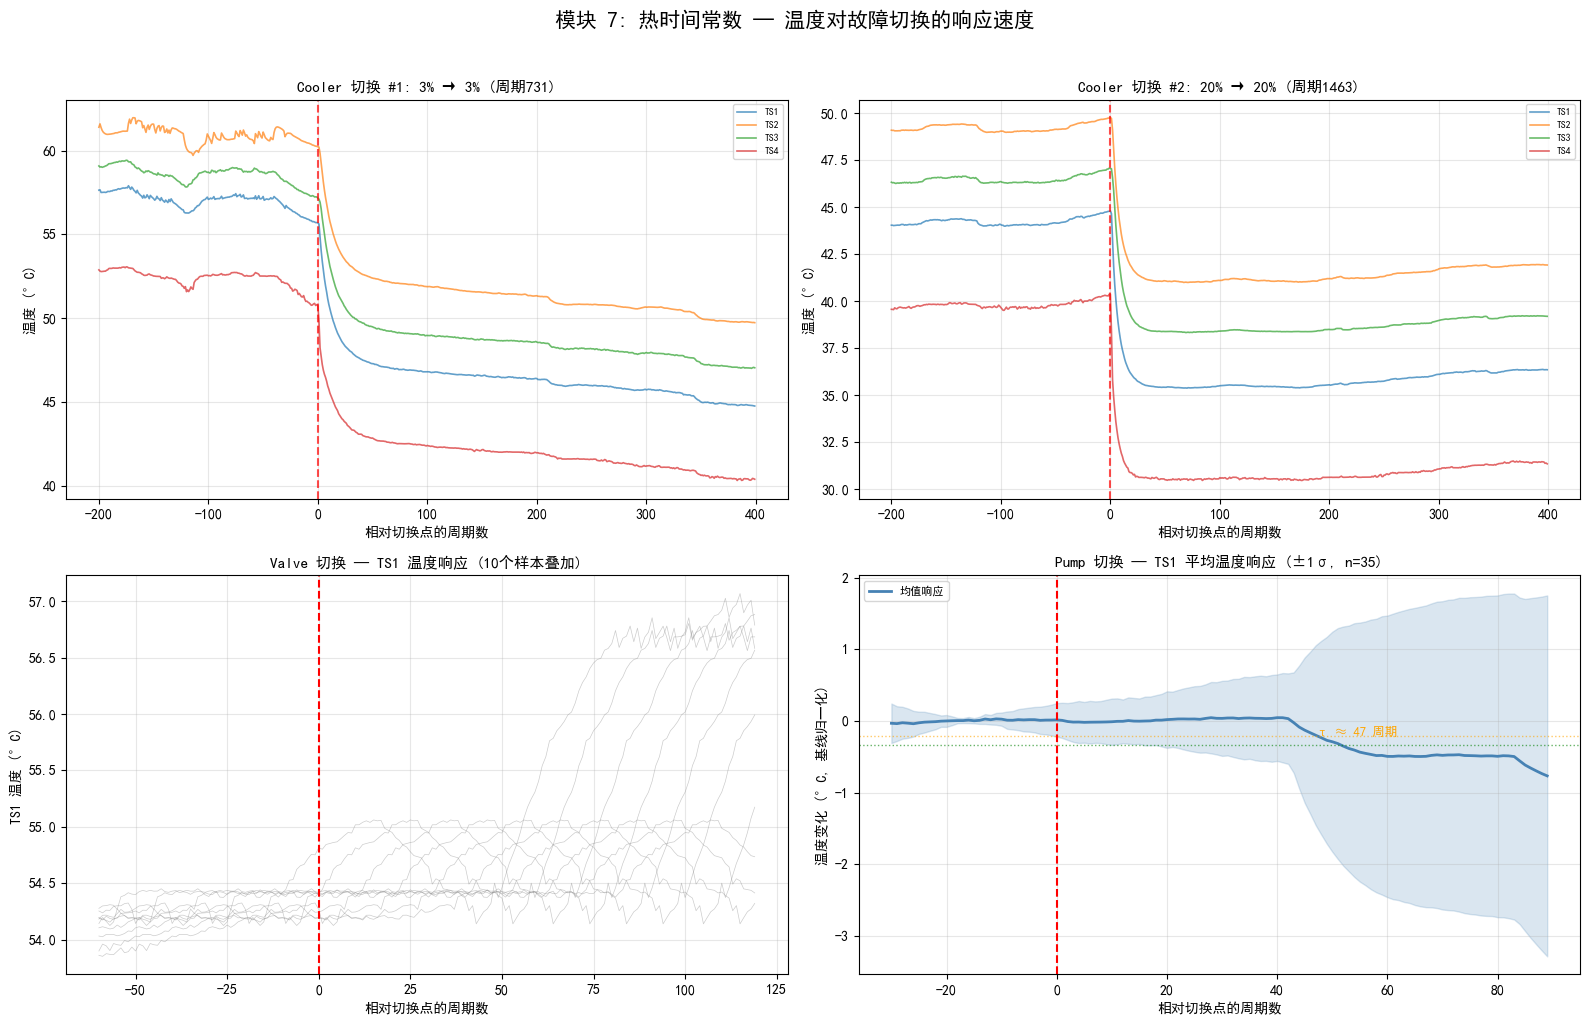

In [8]:
# Cooler switch response (only 2 switches, but dramatic)
cooler_switches = np.where(np.diff(cooler_vals) != 0)[0]
print(f'Cooler 切换点: {list(cooler_switches)}')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1 & 2: Cooler switches with ±200 cycle window
for idx, sw in enumerate(cooler_switches[:2]):
    ax = axes[0, idx]
    start = max(0, sw - 200)
    end = min(2205, sw + 400)
    local_idx = np.arange(start, end) - sw  # relative to switch
    for name in ['TS1', 'TS2', 'TS3', 'TS4']:
        ax.plot(local_idx, ts_means[name].iloc[start:end].values, linewidth=1.2, label=name, alpha=0.7)
    ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    from_state = cooler_vals[sw-1]
    to_state = cooler_vals[sw]
    ax.set_title(f'Cooler 切换 #{idx+1}: {from_state}% → {to_state}% (周期{sw})', fontsize=11)
    ax.set_xlabel('相对切换点的周期数')
    ax.set_ylabel('温度 (°C)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

# Plot 3: Valve switches — average response
valve_vals = profile['Valve'].values
valve_switches = np.where(np.diff(valve_vals) != 0)[0]
valve_switches = valve_switches[(valve_switches > 100) & (valve_switches < 2100)]
print(f'Valve 切换点: {len(valve_switches)} 个 (取前10个可视化)')

ax = axes[1, 0]
for sw in valve_switches[:10]:
    start = max(0, sw - 60)
    end = min(2205, sw + 120)
    local_idx = np.arange(start, end) - sw
    ax.plot(local_idx, ts_means['TS1'].iloc[start:end].values, linewidth=0.5, alpha=0.4, color='gray')
ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
ax.set_title(f'Valve 切换 — TS1 温度响应 (10个样本叠加)', fontsize=11)
ax.set_xlabel('相对切换点的周期数')
ax.set_ylabel('TS1 温度 (°C)')
ax.grid(True, alpha=0.3)

# Plot 4: Pump switches — average response
pump_switches = np.where(np.diff(pump_vals) != 0)[0]
pump_switches = pump_switches[(pump_switches > 50) & (pump_switches < 2150)]
print(f'Pump 切换点: {len(pump_switches)} 个')

ax = axes[1, 1]
all_responses = []
for sw in pump_switches:
    start = max(0, sw - 30)
    end = min(2205, sw + 90)
    if end - start == 120:
        local_data = ts_means['TS1'].iloc[start:end].values
        local_data = local_data - local_data[:30].mean()  # normalize to pre-switch baseline
        all_responses.append(local_data)
if all_responses:
    mean_resp = np.mean(all_responses, axis=0)
    std_resp = np.std(all_responses, axis=0)
    local_idx = np.arange(-30, 90)
    ax.plot(local_idx, mean_resp, 'steelblue', linewidth=2, label='均值响应')
    ax.fill_between(local_idx, mean_resp-std_resp, mean_resp+std_resp, alpha=0.2, color='steelblue')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
    # Thermal time constant estimate: time to reach 63% of final value
    final_val = mean_resp[60:].mean()  # steady state after switch
    target_63 = 0.63 * final_val
    crossing = np.where(np.abs(mean_resp[30:] - target_63) == np.min(np.abs(mean_resp[30:] - target_63)))[0][0]
    tau_est = local_idx[30 + crossing]
    ax.axhline(y=final_val, color='green', linestyle=':', linewidth=1, alpha=0.6)
    ax.axhline(y=target_63, color='orange', linestyle=':', linewidth=1, alpha=0.6)
    ax.annotate(f'τ ≈ {tau_est} 周期', xy=(tau_est, target_63), fontsize=9, color='orange')
    print(f'\nPump切换热时间常数 τ ≈ {tau_est} 周期 (≈ {tau_est*60/60:.1f} 分钟)')
ax.set_title(f'Pump 切换 — TS1 平均温度响应 (±1σ, n={len(all_responses)})', fontsize=11)
ax.set_xlabel('相对切换点的周期数')
ax.set_ylabel('温度变化 (°C, 基线归一化)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle('模块 7: 热时间常数 — 温度对故障切换的响应速度', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 模块 8：总结

In [9]:
print('=' * 68)
print('TS1-4 温度传感器分析 — 总结')
print('=' * 68)
print()
print('1. 温度的核心特征:')
print(f'   - 全局漂移: TS1 从 {ts_means["TS1"].iloc[:100].mean():.1f}→{ts_means["TS1"].iloc[-100:].mean():.1f} °C (Δ={ts_means["TS1"].iloc[-100:].mean()-ts_means["TS1"].iloc[:100].mean():+.1f} °C)')
print(f'   - 周期内波动: TS1-3 < 0.6°C, TS4 可达 {ts4_std.max():.2f}°C')
print(f'   - TS1-4 高度相关: 最低 r={corr.values.min():.3f}')
print()
print('2. 温度故障诊断 F1 (去趋势 5 特征):')
for t in target_config:
    print(f'   {t:<14}: {temp_f1[t]:.4f}')
print()
print('3. 跨传感器排名 (F1 从高到低):')
all_sensors_f1 = {
    'Best Flow': np.mean(list(best_flow_f1.values())),
    'PS1': np.mean(list(ps1_f1.values())),
    'EPS1': 0.9729,
    'Temperature (5feat)': np.mean(list(temp_f1.values())),
    'VS1': np.mean(list(vs1_f1.values())),
}
for name, f1 in sorted(all_sensors_f1.items(), key=lambda x: x[1], reverse=True):
    bar = '█' * int(f1 * 30)
    print(f'   {name:<22}: {f1:.4f}  {bar}')
print()
print('4. 关键发现:')
print(f'   - 温度对 Cooler 诊断能力 {temp_f1["Cooler"]:.3f} — 物理上合理 (冷却器坏了温度高)')
print(f'   - 温度对 Valve 几乎无效 (F1={temp_f1["Valve"]:.3f}) — 阀门不影响热平衡')
print(f'   - TS4 的波动性是独特信号: 异常周期 {len(outlier_idx)} 个')
print(f'   - 温度的真正价值: 长期热平衡监测，而非单周期故障分类')
print(f'   - 热时间常数 ~几十周期 — 温度响应远慢于故障切换速率')
print()
print('5. 最终建议:')
print('   温度传感器不适合做实时故障诊断（响应太慢）')
print('   但可以做: (a) 系统热健康长期监测 (b) 冷却器性能退化跟踪')
print('   (c) 与其他传感器融合时提供热上下文')
print()
print('=' * 68)
print('TS1-4 Analysis complete.')

TS1-4 温度传感器分析 — 总结

1. 温度的核心特征:
   - 全局漂移: TS1 从 49.9→35.6 °C (Δ=-14.3 °C)
   - 周期内波动: TS1-3 < 0.6°C, TS4 可达 1.44°C
   - TS1-4 高度相关: 最低 r=0.998

2. 温度故障诊断 F1 (去趋势 5 特征):
   Cooler        : 0.7449
   Valve         : 0.5385
   Pump_Leakage  : 0.6644
   Accumulator   : 0.5344

3. 跨传感器排名 (F1 从高到低):
   Best Flow             : 0.9882  █████████████████████████████
   PS1                   : 0.9876  █████████████████████████████
   EPS1                  : 0.9729  █████████████████████████████
   Temperature (5feat)   : 0.6206  ██████████████████
   VS1                   : 0.5795  █████████████████

4. 关键发现:
   - 温度对 Cooler 诊断能力 0.745 — 物理上合理 (冷却器坏了温度高)
   - 温度对 Valve 几乎无效 (F1=0.539) — 阀门不影响热平衡
   - TS4 的波动性是独特信号: 异常周期 23 个
   - 温度的真正价值: 长期热平衡监测，而非单周期故障分类
   - 热时间常数 ~几十周期 — 温度响应远慢于故障切换速率

5. 最终建议:
   温度传感器不适合做实时故障诊断（响应太慢）
   但可以做: (a) 系统热健康长期监测 (b) 冷却器性能退化跟踪
   (c) 与其他传感器融合时提供热上下文

TS1-4 Analysis complete.
